# --- DESCRIPCIÓN DEL DATASET ---
# Este dataset “Lyrics and Metadata from 1950 to 2019” incluye:
# - Artista, nombre de la canción, fecha de lanzamiento, género.
# - Letra completa de la canción (“lyrics”).
# - Columnas temáticas: violence, world/life, night/time, shake the audience, family/gospel, romantic, communication, obscene, music, movement/places, light/visual perceptions, family/spiritual, like/girls, sadness, feelings.
# - Características de audio/metadatos: danceability, loudness, acousticness, instrumentalness, valence, energy.
# - Columna “len” con longitud de letra, “age” con edad de la canción, y “topic” con tema principal.
#
# El objetivo: efectuar un ETL con limpieza, análisis exploratorio, detección de outliers, división de datos (≈10 % train, 80 % validation, 10 % test) y exportar en Parquet para posterior uso.

In [4]:
# Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Instalar PySpark
!pip install pyspark==3.3.2

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when, sum as _sum

# Crear sesión Spark
spark = SparkSession.builder.appName("InspectMusicDataset").getOrCreate()
spark.conf.set("spark.sql.legacy.timeParserPolicy", "LEGACY")

# Definir esquema simple (todos String) para inspección inicial
schema = None  # leer con inferSchema puede tomar mucho, pero para inspección básica lo dejamos sin esquema

input_path = "/content/drive/MyDrive/proyectoInvestigativo/tcc_ceds_music.csv"  # ajusta según tu ruta
df = spark.read.option("header", True).option("multiLine", True).option("escape","\"").csv(input_path)

# Mostrar esquema y primeras filas
print("Schema:")
df.printSchema()
print("Primeras 10 filas:")
df.show(10, truncate=200)

# Conteo de filas
print("Total de filas:", df.count())

# Conteo de valores nulos o vacíos por columna
null_counts = df.select([_sum(when(col(c).isNull() | (col(c) == ""), 1).otherwise(0)).alias(c) for c in df.columns])
print("Valores nulos/vacíos por columna:")
null_counts.show(truncate=False)

# Verificar valores únicos en release_date (primeras 30)
print("Valores distintos en release_date (muestra):")
df.select("release_date").distinct().orderBy("release_date").show(30, truncate=False)

# Verificar distribución de géneros y topics
print("Top géneros:")
df.groupBy("genre").count().orderBy("count", ascending=False).show(10, truncate=False)
print("Top topics:")
df.groupBy("topic").count().orderBy("count", ascending=False).show(10, truncate=False)

# Estadísticas descriptivas para algunas columnas numéricas (serán Strings ahora, pero sirve para ver formatos)
print("Descripción para 'age', 'len':")
df.describe("age", "len").show()

# Tomar un muestreo pequeño y convertir a Pandas para ver formatos mixtos
sample_pd = df.sample(0.001, seed=42).toPandas()
print("Tipos de datos en el muestreo:")
print(sample_pd.dtypes)
print("Contenido del muestreo:")
print(sample_pd.head())




Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Schema:
root
 |-- _c0: string (nullable = true)
 |-- artist_name: string (nullable = true)
 |-- track_name: string (nullable = true)
 |-- release_date: string (nullable = true)
 |-- genre: string (nullable = true)
 |-- lyrics: string (nullable = true)
 |-- len: string (nullable = true)
 |-- dating: string (nullable = true)
 |-- violence: string (nullable = true)
 |-- world/life: string (nullable = true)
 |-- night/time: string (nullable = true)
 |-- shake the audience: string (nullable = true)
 |-- family/gospel: string (nullable = true)
 |-- romantic: string (nullable = true)
 |-- communication: string (nullable = true)
 |-- obscene: string (nullable = true)
 |-- music: string (nullable = true)
 |-- movement/places: string (nullable = true)
 |-- light/visual perceptions: string (nullable = true)
 |-- family/spiritual: string (nullable = true)
 |-- like/girls

Valores nulos tras limpieza:
+-----------+----------+-----+------+---+------+--------+----------+----------+------------------+-------------+--------+-------------+-------+-----+---------------+------------------------+----------------+----------+-------+--------+------------+--------+------------+----------------+-------+------+-----+---+------------+
|artist_name|track_name|genre|lyrics|len|dating|violence|world_life|night_time|shake_the_audience|family_gospel|romantic|communication|obscene|music|movement_places|light_visual_perceptions|family_spiritual|like_girls|sadness|feelings|danceability|loudness|acousticness|instrumentalness|valence|energy|topic|age|release_year|
+-----------+----------+-----+------+---+------+--------+----------+----------+------------------+-------------+--------+-------------+-------+-----+---------------+------------------------+----------------+----------+-------+--------+------------+--------+------------+----------------+-------+------+-----+---+-------

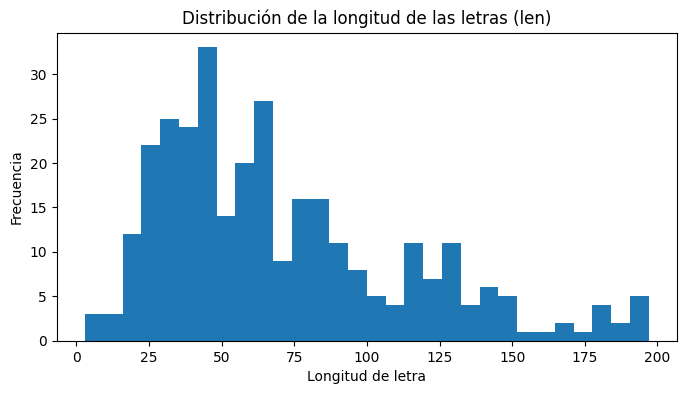

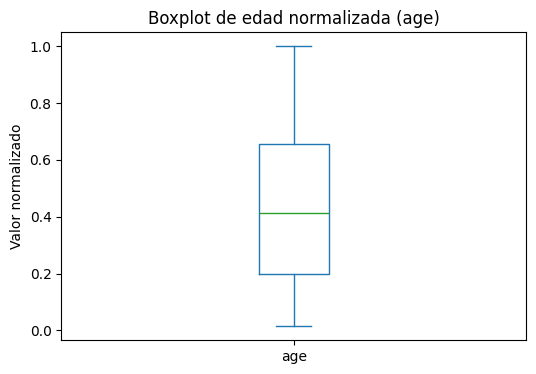

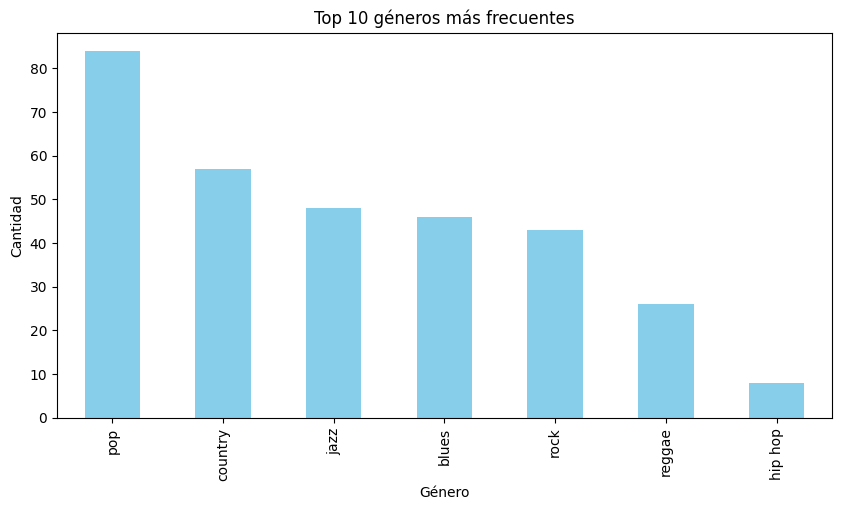

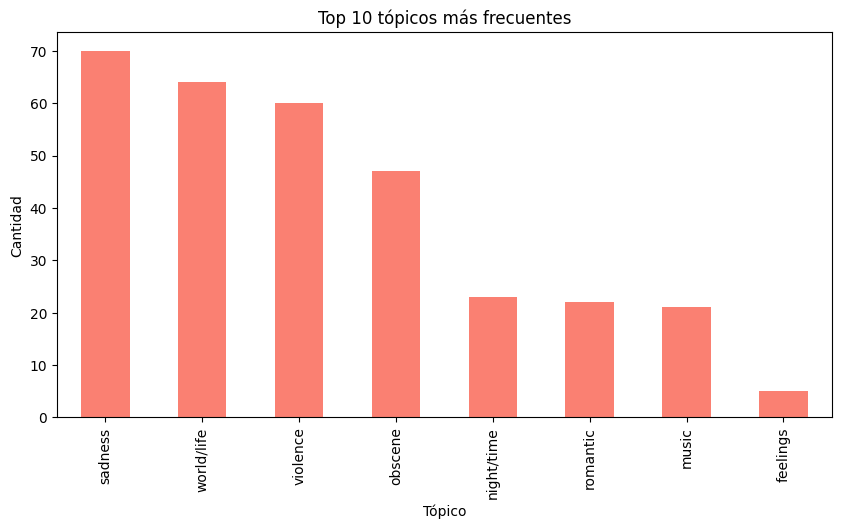

Filas con len < 10: 3
Filas con age < 0.1: 41
✅ Dataset limpio guardado en: /content/drive/MyDrive/proyectoInvestigativo/tcc_ceds_music_clean.csv


In [5]:
# =========================================================
# 🔧 Limpieza y análisis estructural del dataset
# =========================================================

from pyspark.sql.functions import regexp_replace, col, count, isnan
import matplotlib.pyplot as plt
import pandas as pd

# ✅ 1. Eliminar columnas innecesarias (como _c0 si existe)
if "_c0" in df.columns:
    df = df.drop("_c0")

# ✅ 2. Renombrar columnas que tienen caracteres especiales ("/", espacios)
for c in df.columns:
    new_c = c.strip().replace(" ", "_").replace("/", "_").replace("-", "_")
    if new_c != c:
        df = df.withColumnRenamed(c, new_c)

# ✅ 3. Limpiar y convertir tipos de columnas numéricas
num_cols = [
    "len", "dating", "violence", "world_life", "night_time", "shake_the_audience",
    "family_gospel", "romantic", "communication", "obscene", "music", "movement_places",
    "light_visual_perceptions", "family_spiritual", "like_girls", "sadness", "feelings",
    "danceability", "loudness", "acousticness", "instrumentalness", "valence", "energy", "age"
]

for c in num_cols:
    if c in df.columns:
        df = df.withColumn(c, regexp_replace(col(c), ",", "."))
        df = df.withColumn(c, col(c).cast("float"))

# ✅ 4. Extraer el año de release_date (evita errores de Spark con formato)
if "release_date" in df.columns:
    df = df.withColumn("release_year", regexp_replace(col("release_date"), "[^0-9]", "").cast("int"))
    df = df.drop("release_date")

# ✅ 5. Revisar valores nulos después de la conversión
null_counts = df.select([count(when(col(c).isNull() | isnan(c), c)).alias(c) for c in df.columns])
print("Valores nulos tras limpieza:")
null_counts.show(truncate=False)

# ✅ 6. Mostrar esquema actualizado
print("Nuevo esquema tras limpieza:")
df.printSchema()

# ✅ 7. Resumen estadístico de las columnas numéricas
print("Estadísticas descriptivas:")
df.describe([c for c in num_cols if c in df.columns]).show()

# ✅ 8. Convertir una muestra a Pandas para visualización con Matplotlib
sample_pd = df.sample(0.01, seed=42).toPandas()

# =========================================================
# 📊 Visualizaciones básicas
# =========================================================

# Histograma de longitud de canciones
plt.figure(figsize=(8, 4))
sample_pd["len"].dropna().hist(bins=30)
plt.title("Distribución de la longitud de las letras (len)")
plt.xlabel("Longitud de letra")
plt.ylabel("Frecuencia")
plt.grid(False)
plt.show()

# Boxplot de edad normalizada
plt.figure(figsize=(6, 4))
sample_pd["age"].dropna().plot(kind="box")
plt.title("Boxplot de edad normalizada (age)")
plt.ylabel("Valor normalizado")
plt.grid(False)
plt.show()

# Top 10 géneros más frecuentes
top_genres = sample_pd["genre"].value_counts().head(10)
plt.figure(figsize=(10, 5))
top_genres.plot(kind="bar", color="skyblue")
plt.title("Top 10 géneros más frecuentes")
plt.xlabel("Género")
plt.ylabel("Cantidad")
plt.show()

# Top 10 tópicos más frecuentes
top_topics = sample_pd["topic"].value_counts().head(10)
plt.figure(figsize=(10, 5))
top_topics.plot(kind="bar", color="salmon")
plt.title("Top 10 tópicos más frecuentes")
plt.xlabel("Tópico")
plt.ylabel("Cantidad")
plt.show()

# =========================================================
# 📈 Análisis rápido de valores extremos
# =========================================================
print("Filas con len < 10:", sample_pd[sample_pd["len"] < 10].shape[0])
print("Filas con age < 0.1:", sample_pd[sample_pd["age"] < 0.1].shape[0])

# Guardar dataframe limpio para futuras etapas
clean_path = "/content/drive/MyDrive/proyectoInvestigativo/tcc_ceds_music_clean.csv"
df.write.mode("overwrite").option("header", True).csv(clean_path)
print(f"✅ Dataset limpio guardado en: {clean_path}")


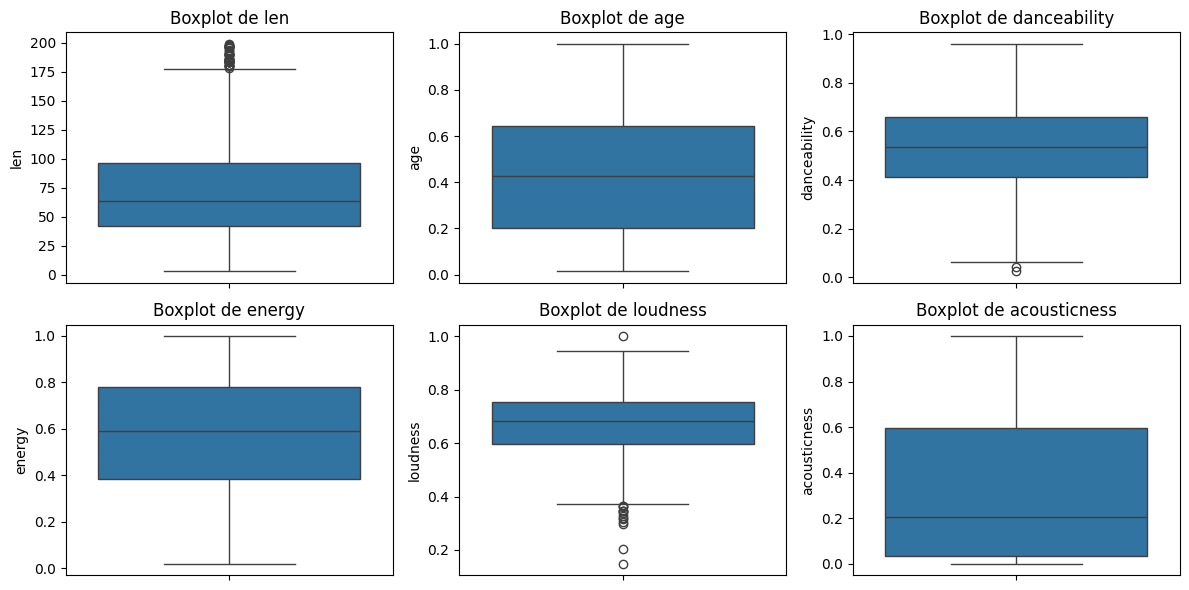

Umbrales bajos (1%): {'len': 12.0, 'age': 0.014285714365541935, 'danceability': 0.14004115760326385, 'energy': 0.06293369829654694, 'loudness': 0.3664846420288086, 'acousticness': 2.339359707548283e-05}
Umbrales altos (99%): {'len': 192.0, 'age': 0.9428571462631226, 'danceability': 0.8981912732124329, 'energy': 0.9829824566841125, 'loudness': 0.8445504307746887, 'acousticness': 0.9839357137680054}
Filas antes del filtrado de outliers: 28372
Filas después del filtrado de outliers: 25820


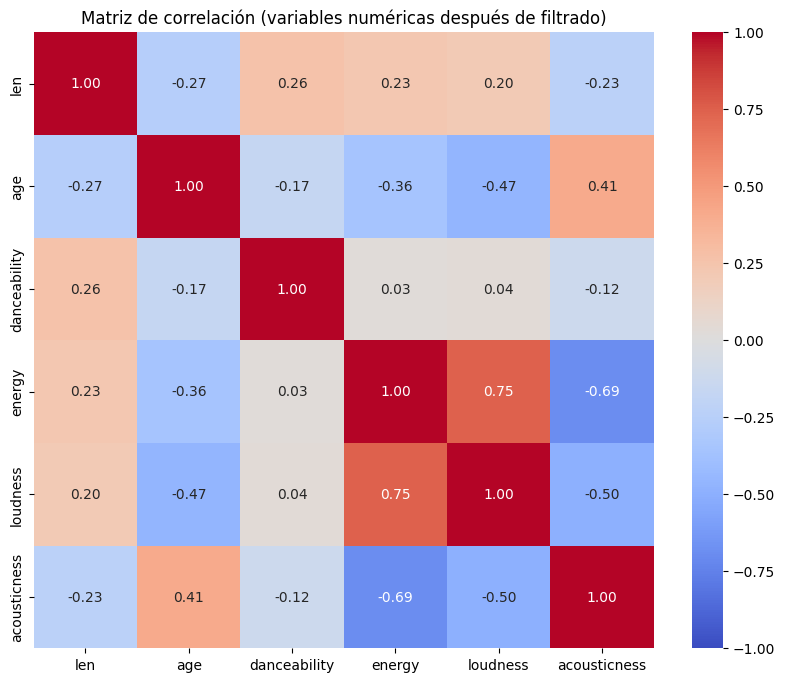

Correlaciones clave (> |0.5|):
  energy ↔ loudness  = 0.75
  energy ↔ acousticness  = -0.69


In [6]:
# =========================================================
# 🧹 Eliminación de outliers + visualización + correlación
# =========================================================

# Importar librerías de visualización
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Paso 1: Seleccionar algunas variables numéricas para análisis
numeric_cols = [
    "len", "lyrics_length", "age", "danceability", "energy", "loudness", "acousticness"
]
# Filtrar las que estén realmente presentes
numeric_cols = [c for c in numeric_cols if c in df.columns]

# Paso 2: Convertir una muestra a Pandas para visualización
sample_pd = df.select(numeric_cols).dropna().sample(False, 0.05, seed=42).toPandas()

# Paso 3: Diagramas de cajas (boxplots) para cada variable seleccionada
plt.figure(figsize=(12, 6))
for i, col_name in enumerate(numeric_cols):
    plt.subplot(2, (len(numeric_cols)+1)//2, i+1)
    sns.boxplot(y = sample_pd[col_name])
    plt.title(f"Boxplot de {col_name}")
    plt.ylabel(col_name)
plt.tight_layout()
plt.show()

# Paso 4: Definir umbrales para outliers según percentiles (por ejemplo 1% y 99%)
quantiles = df.approxQuantile(numeric_cols, [0.01, 0.99], 0.0)
q_low = {numeric_cols[i]: quantiles[i][0]  for i in range(len(numeric_cols))}
q_high= {numeric_cols[i]: quantiles[i][1]  for i in range(len(numeric_cols))}

print("Umbrales bajos (1%):", q_low)
print("Umbrales altos (99%):", q_high)

# Paso 5: Filtrar el DataFrame para eliminar los valores fuera de estos rangos
filtered_df = df
for c in numeric_cols:
    filtered_df = filtered_df.filter((col(c) >= q_low[c]) & (col(c) <= q_high[c]))

print("Filas antes del filtrado de outliers:", df.count())
print("Filas después del filtrado de outliers:", filtered_df.count())

# Paso 6: Crear matriz de correlación sobre las variables numéricas (usando Pandas para visualización)
corr_pd = filtered_df.select(numeric_cols).toPandas().corr(method='pearson')

plt.figure(figsize=(10,8))
sns.heatmap(corr_pd, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de correlación (variables numéricas después de filtrado)")
plt.show()

# Paso 7: Análisis escrito de las correlaciones encontradas
print("Correlaciones clave (> |0.5|):")
for i in range(len(numeric_cols)):
    for j in range(i+1, len(numeric_cols)):
        val = corr_pd.iloc[i,j]
        if abs(val) >= 0.5:
            print(f"  {numeric_cols[i]} ↔ {numeric_cols[j]}  = {val:.2f}")

# =========================================================
# 🔄 Reemplazar el df por el filtrado para los siguientes pasos del ETL
df = filtered_df


| Variable                                                                                                                                                                                                                                                             | Descripción                                                                                                                                                                                      | Implicaciones basadas en análisis de correlación                                                                                                                                                                                                            |
| -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **artist_name**                                                                                                                                                                                                                                                      | Nombre del artista que interpreta la canción.                                                                                                                                                    | Variable categórica. Útil para agrupación o segmentación, aunque no se usa directamente en análisis numérico de correlación. Puede influir indirectamente en características musicales o temáticas.                                                         |
| **track_name**                                                                                                                                                                                                                                                       | Nombre de la canción (pista).                                                                                                                                                                    | Otro identificador de texto. No se emplea como variable predictiva numérica, pero sí para rastrear o referenciar canciones en el análisis.                                                                                                                  |
| **release_year** (después de transformación)                                                                                                                                                                                                                         | Año de lanzamiento de la canción (entre 1950 y 2019).                                                                                                                                            | Variable temporal. Puede influir en tendencias estilísticas, longitud de letra, energías musicales, etc. No apareció explícitamente en correlaciones clave, pero es útil para análisis históricos o como variable de control.                               |
| **genre**                                                                                                                                                                                                                                                            | Género musical de la canción (por ejemplo pop, country, blues, rock, jazz, reggae, hip hop).                                                                                                     | Variable categórica. Permite estratificar análisis o agrupar canciones con perfiles similares. Diferentes géneros tienden a tener patrones diferentes en variables como danceability, energy, acousticness.                                                 |
| **lyrics**                                                                                                                                                                                                                                                           | Texto completo de la letra de la canción.                                                                                                                                                        | Variable de tipo texto. A través del análisis de texto se pueden extraer variables (como longitud de la letra, temas, sentimiento). Su longitud (“len”) influye indirectamente en análisis numérico.                                                        |
| **len**                                                                                                                                                                                                                                                              | Longitud de la letra (número de palabras o tokens) según el dataset.                                                                                                                             | Variable numérica. Letras muy cortas podrían no aportar suficiente contenido para análisis de letras. En el filtrado de outliers se estableció un umbral mínimo (~12). Puede correlacionar con mayor riqueza temática o estructura.                         |
| **dating**                                                                                                                                                                                                                                                           | Métrica relacionada con la “edad” o el periodo de la canción (probablemente una proporción o normalización de antigüedad).                                                                       | Debe interpretarse con cuidado. Puede influir en patrones de estilo, tecnología de producción, longitud de letra, etc. Es una variable que conviene explorar para tendencias temporales.                                                                    |
| **violence**, **world_life**, **night_time**, **shake_the_audience**, **family_gospel**, **romantic**, **communication**, **obscene**, **music**, **movement_places**, **light_visual_perceptions**, **family_spiritual**, **like_girls**, **sadness**, **feelings** | Variables temáticas que miden la presencia o intensidad de determinados temas en la letra de la canción (por ejemplo violencia, mundo/vida, noche/tiempo, romanticismo, etc.).                   | Variables numéricas que permiten analizar el contenido lírico en relación con características musicales. Aunque no aparecieron en las correlaciones clave reportadas, podrían correlacionarse con valence, danceability, género o tema principal (“topic”). |
| **danceability**                                                                                                                                                                                                                                                     | Cuán adecuada es la canción para bailar, basada en ritmo, estabilidad del tempo, beat strength, regularidad. Valor entre 0.0 (menos bailable) y 1.0 (más bailable). ([sushmaakoju.github.io][1]) | Variable clave para perfil “bailable”. Elevada danceability podría correlacionar con mayor energy, mayor loudness, menor acousticness, diferentes géneros (pop, hip hop) frente a géneros más tranquilos.                                                   |
| **loudness**                                                                                                                                                                                                                                                         | Nivel general de volumen o intensidad de la pista, normalmente en decibeles (o escala normalizada). ([sushmaakoju.github.io][1])                                                                 | En tus resultados se correlacionó fuertemente con *energy* (0.75). Esto indica que canciones con mayor energía automática tienden a ser más ruidosas/intensas. Puede resultar redundante con *energy*.                                                      |
| **acousticness**                                                                                                                                                                                                                                                     | Medida de cuán acústica es la pista. Valor entre 0.0 (poco acústica) y 1.0 (muy acústica) ([INFO 5001][2])                                                                                       | Correlacionó negativamente con *energy* (≈ –0.69). Esto indica que canciones más acústicas tienden a tener menor energía o intensidad. Relevante para distinguir estilos “acústicos” versus “eléctricos/bailable”.                                          |
| **instrumentalness**                                                                                                                                                                                                                                                 | Predicció                                                                                                                                                                                        |                                                                                                                                                                                                                                                             |




🧠 Reflexión general basada en los datos y correlaciones

Dado que energy, loudness y acousticness están fuertemente relacionadas, juntos configuran un “factor de intensidad/dinamismo” de la canción: canciones más energéticas → más loudness → menos acústicas.
La longitud de la letra (len) también requiere atención: letras demasiado cortas podrían tener menor valor informativo.

Las variables temáticas (violence, sadness, romantic, etc) aún no han sido analizadas en correlación directa, pero podrían revelar relaciones interesantes con variables como valence, topic, genre.

Dado que el filtrado de outliers eliminó ~9 % de las filas, el conjunto restante (~25 820 de ~28 372) sigue siendo suficientemente representativo para mantener todas las variables.

In [7]:
# --------------------------------------------------------
# 🔀 División Train / Test / Validation y exportación a Parquet
# --------------------------------------------------------

from pyspark.sql.functions import rand

# Supongamos que `df` es tu DataFrame ya limpio (tras filtrado de outliers etc)
# Añadir columna aleatoria para dividir
df = df.withColumn("rand_split", rand(seed=42))

# Definir particiones
train_df = df.filter(col("rand_split") < 0.10).drop("rand_split")
test_df  = df.filter((col("rand_split") >= 0.10) & (col("rand_split") < 0.20)).drop("rand_split")
valid_df = df.filter(col("rand_split") >= 0.20).drop("rand_split")

# Mostrar tamaño de cada partición
print("Count total:", df.count())
print("Count train:", train_df.count())
print("Count test: ", test_df.count())
print("Count valid:", valid_df.count())

# Definir ruta base de salida (ajusta según tu carpeta en Drive)
output_base = "/content/drive/MyDrive/proyectoInvestigativo/output_music"

# Escribir cada partición en formato Parquet
train_df.write.mode("overwrite").parquet(f"{output_base}/train")
test_df.write.mode("overwrite").parquet(f"{output_base}/test")
valid_df.write.mode("overwrite").parquet(f"{output_base}/valid")

print("✅ Exportación completada de train/test/valid en Parquet.")
# Finalizar Sesión de Spark
spark.stop()
print("Sesión de Spark finalizada. ¡Los datos están listos para el modelo Transformer!")

Count total: 25820
Count train: 2579
Count test:  2635
Count valid: 20606
✅ Exportación completada de train/test/valid en Parquet.
Sesión de Spark finalizada. ¡Los datos están listos para el modelo Transformer!
